In [52]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (f1_score, roc_auc_score, recall_score, precision_score, confusion_matrix)

In [53]:
from sklearn.datasets import make_classification

X, y = make_classification(
    n_samples    = 2000,
    n_features   = 20,
    n_informative= 5,
    n_redundant  = 10,
    flip_y       = 0.05,
    random_state = 42
)

# Split into train, validation and test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.15, random_state=42)

# Normalize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

print(f"Train : {X_train.shape}")
print(f"Val   : {X_val.shape}")
print(f"Test  : {X_test.shape}")

Train : (1445, 20)
Val   : (255, 20)
Test  : (300, 20)


In [54]:
def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

In [55]:
def init_weights(layer_sizes):
    weights, biases = [], []
    for i in range(len(layer_sizes) - 1):
        scale = np.sqrt(2.0 / layer_sizes[i])
        weights.append(np.random.randn(layer_sizes[i], layer_sizes[i+1]) * scale)
        biases.append(np.zeros((1, layer_sizes[i+1])))
    return weights, biases

print("Weight initialization defined")


Weight initialization defined


In [56]:
def forward(X, weights, biases, dropout_rate=0.0, training=True):
    A = X
    cache = [A]
    masks = []

    for i in range(len(weights) - 1):
        Z = A @ weights[i] + biases[i]
        A = relu(Z)
        if training and dropout_rate > 0:
            mask = (np.random.rand(*A.shape) > dropout_rate) / (1 - dropout_rate)
            A = A * mask
        else:
            mask = np.ones_like(A)
        masks.append(mask)
        cache.append(A)

    # Output layer - sigmoid
    Z = A @ weights[-1] + biases[-1]
    A = sigmoid(Z)
    cache.append(A)

    return cache, masks

print("Forward pass defined")

Forward pass defined


In [57]:
def compute_loss(y, y_hat, weights, l1_lambda=0, l2_lambda=0):
    m = y.shape[0]
    y = y.reshape(-1, 1)
    eps = 1e-9
    # Binary cross entropy loss
    bce = -np.mean(y * np.log(y_hat + eps) + (1 - y) * np.log(1 - y_hat + eps))

    # L1 penalty
    l1_term = (l1_lambda / m) * sum(np.sum(np.abs(w)) for w in weights)

    # L2 penalty
    l2_term = (l2_lambda / (2 * m)) * sum(np.sum(w ** 2) for w in weights)
    return bce + l1_term + l2_term

print("Loss defined")

Loss defined


In [58]:
def backward(y, cache, masks, weights, biases, l1_lambda=0, l2_lambda=0):
    m = y.shape[0]
    y = y.reshape(-1, 1)
    L = len(weights)

    dW_list = []
    db_list = []

    # Gradient at output layer
    dA = cache[-1] - y
    
    for i in range(L - 1, -1, -1):
        A_prev = cache[i]
        
        dW = (A_prev.T @ dA) / m
        db = np.mean(dA, axis=0, keepdims=True)

        # L1 gradient
        dW += (l1_lambda / m) * np.sign(weights[i])

        # L2 gradient
        dW += (l2_lambda / m) * weights[i]

        dW_list.insert(0, dW)
        db_list.insert(0, db)

        if i > 0:
            dA = dA @ weights[i].T
            dA = dA * masks[i - 1]
            dA = dA * relu_derivative(cache[i])

    return dW_list, db_list

print("Backward pass defined")




# layer_sizes = [8, 64, 64, 1]
# weights_test, biases_test = init_weights(layer_sizes)
# cache_test, masks_test = forward(X_train[:10], weights_test, biases_test)
# dW_list_test, db_list_test = backward(y_train[:10], cache_test, masks_test, weights_test, biases_test)
# print("Gradient shapes per layer:")
# for i, dW in enumerate(dW_list_test):
#     print(f"  Layer {i+1} → dW shape: {dW.shape}")

Backward pass defined


In [59]:
def update_params(weights, biases, dW_list, db_list, lr):
    for i in range(len(weights)):
        weights[i] -= lr * dW_list[i]
        biases[i]  -= lr * db_list[i]
    return weights, biases

print("Parameter update defined")

Parameter update defined


In [60]:
def train(X_train, y_train, X_val, y_val, layer_sizes, epochs, lr,
          dropout_rate=0.0, l1_lambda=0, l2_lambda=0):

    weights, biases = init_weights(layer_sizes)

    train_losses, val_losses     = [], []
    train_accuracies, val_accuracies = [], []

    for epoch in range(epochs):

        # Forward pass on training data
        cache, masks = forward(X_train, weights, biases,
                               dropout_rate=dropout_rate, training=True)
        y_hat_train = cache[-1]

        # Compute training loss
        loss_train = compute_loss(y_train, y_hat_train, weights,
                                  l1_lambda=l1_lambda, l2_lambda=l2_lambda)

        # Backward pass
        dW_list, db_list = backward(y_train, cache, masks, weights, biases,
                                    l1_lambda=l1_lambda, l2_lambda=l2_lambda)

        # Update parameters
        weights, biases = update_params(weights, biases, dW_list, db_list, lr)

        # Forward pass on validation data (no dropout)
        cache_val, masks_val = forward(X_val, weights, biases,
                                       dropout_rate=0.0, training=False)
        y_hat_val = cache_val[-1]

        # Compute validation loss
        loss_val = compute_loss(y_val, y_hat_val, weights,
                                l1_lambda=l1_lambda, l2_lambda=l2_lambda)

        # Compute accuracies
        train_acc = np.mean((y_hat_train >= 0.5).flatten() == y_train)
        val_acc   = np.mean((y_hat_val   >= 0.5).flatten() == y_val)

        # Store metrics
        train_losses.append(loss_train)
        val_losses.append(loss_val)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)

        # Print every 10 epochs
        if (epoch + 1) % 30 == 0:
            print(f"Epoch {epoch+1}/{epochs} | "
                  f"Train Loss: {loss_train:.4f} | Val Loss: {loss_val:.4f} | "
                  f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

    return weights, biases, train_losses, val_losses, train_accuracies, val_accuracies

print("Training loop defined")

Training loop defined


In [61]:
# Deliberately overfit - very large network, more epochs, high lr
layer_sizes = [20, 256, 256, 128, 64, 1]

weights_overfit, biases_overfit, train_losses_overfit, val_losses_overfit, \
train_acc_overfit, val_acc_overfit = train(
    X_train, y_train, X_val, y_val,
    layer_sizes = layer_sizes,
    epochs      = 300,
    lr          = 0.1,
    dropout_rate= 0.0,
    l1_lambda   = 0,
    l2_lambda   = 0
)

print("\nOverfit Model Summary:")
print(f"  Final Train Loss : {train_losses_overfit[-1]:.4f}")
print(f"  Final Val Loss   : {val_losses_overfit[-1]:.4f}")
print(f"  Final Train Acc  : {train_acc_overfit[-1]:.4f}")
print(f"  Final Val Acc    : {val_acc_overfit[-1]:.4f}")
print(f"  Loss Gap         : {val_losses_overfit[-1] - train_losses_overfit[-1]:.4f}")

Epoch 30/300 | Train Loss: 0.2743 | Val Loss: 0.2869 | Train Acc: 0.8990 | Val Acc: 0.8824
Epoch 60/300 | Train Loss: 0.2256 | Val Loss: 0.2768 | Train Acc: 0.9204 | Val Acc: 0.8745
Epoch 90/300 | Train Loss: 0.2025 | Val Loss: 0.2857 | Train Acc: 0.9301 | Val Acc: 0.8627
Epoch 120/300 | Train Loss: 0.1871 | Val Loss: 0.2984 | Train Acc: 0.9315 | Val Acc: 0.8784
Epoch 150/300 | Train Loss: 0.1829 | Val Loss: 0.3098 | Train Acc: 0.9273 | Val Acc: 0.8745
Epoch 180/300 | Train Loss: 0.1400 | Val Loss: 0.2931 | Train Acc: 0.9529 | Val Acc: 0.8706
Epoch 210/300 | Train Loss: 0.1169 | Val Loss: 0.2942 | Train Acc: 0.9647 | Val Acc: 0.8784
Epoch 240/300 | Train Loss: 0.1034 | Val Loss: 0.2960 | Train Acc: 0.9696 | Val Acc: 0.8784
Epoch 270/300 | Train Loss: 0.1004 | Val Loss: 0.2957 | Train Acc: 0.9702 | Val Acc: 0.8824
Epoch 300/300 | Train Loss: 0.0807 | Val Loss: 0.3199 | Train Acc: 0.9751 | Val Acc: 0.8784

Overfit Model Summary:
  Final Train Loss : 0.0807
  Final Val Loss   : 0.3199
  F

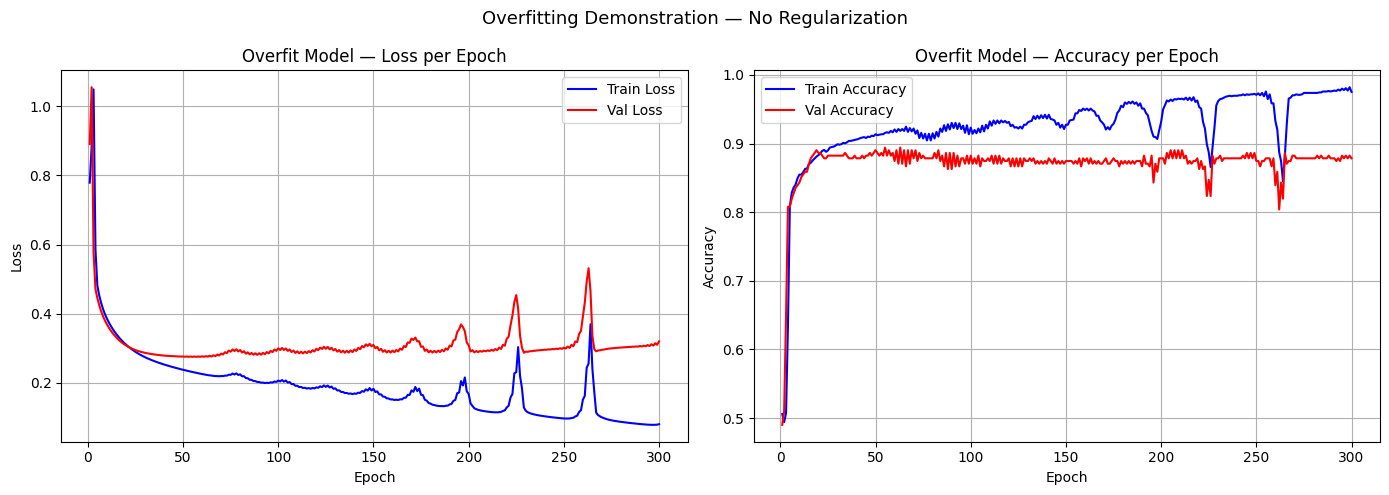

In [62]:
epochs_range = range(1, 301)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
axes[0].plot(epochs_range, train_losses_overfit, label='Train Loss',     color='blue')
axes[0].plot(epochs_range, val_losses_overfit,   label='Val Loss',       color='red')
axes[0].set_title('Overfit Model — Loss per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy curves
axes[1].plot(epochs_range, train_acc_overfit,    label='Train Accuracy', color='blue')
axes[1].plot(epochs_range, val_acc_overfit,      label='Val Accuracy',   color='red')
axes[1].set_title('Overfit Model — Accuracy per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Overfitting Demonstration — No Regularization', fontsize=13)
plt.tight_layout()
plt.show()

In [64]:
layer_sizes = [20, 256, 256, 128, 64, 1]

weights_l1, biases_l1, train_losses_l1, val_losses_l1, \
train_acc_l1, val_acc_l1 = train(
    X_train, y_train, X_val, y_val,
    layer_sizes  = layer_sizes,
    epochs       = 300,
    lr           = 0.01,
    dropout_rate = 0.0,
    l1_lambda    = 0.005,
    l2_lambda    = 0.0
)

print("\nL1 Regularization Summary:")
print(f"  Final Train Loss : {train_losses_l1[-1]:.4f}")
print(f"  Final Val Loss   : {val_losses_l1[-1]:.4f}")
print(f"  Final Train Acc  : {train_acc_l1[-1]:.4f}")
print(f"  Final Val Acc    : {val_acc_l1[-1]:.4f}")
print(f"  Loss Gap         : {val_losses_l1[-1] - train_losses_l1[-1]:.4f}")

Epoch 30/300 | Train Loss: 0.5241 | Val Loss: 0.6695 | Train Acc: 0.7903 | Val Acc: 0.8078
Epoch 60/300 | Train Loss: 0.4507 | Val Loss: 0.5951 | Train Acc: 0.8339 | Val Acc: 0.8471
Epoch 90/300 | Train Loss: 0.4069 | Val Loss: 0.5526 | Train Acc: 0.8595 | Val Acc: 0.8706
Epoch 120/300 | Train Loss: 0.3775 | Val Loss: 0.5256 | Train Acc: 0.8720 | Val Acc: 0.8824
Epoch 150/300 | Train Loss: 0.3563 | Val Loss: 0.5079 | Train Acc: 0.8789 | Val Acc: 0.8941
Epoch 180/300 | Train Loss: 0.3404 | Val Loss: 0.4960 | Train Acc: 0.8844 | Val Acc: 0.8863
Epoch 210/300 | Train Loss: 0.3277 | Val Loss: 0.4878 | Train Acc: 0.8907 | Val Acc: 0.8863
Epoch 240/300 | Train Loss: 0.3172 | Val Loss: 0.4816 | Train Acc: 0.8955 | Val Acc: 0.8902
Epoch 270/300 | Train Loss: 0.3082 | Val Loss: 0.4769 | Train Acc: 0.9017 | Val Acc: 0.8941
Epoch 300/300 | Train Loss: 0.3005 | Val Loss: 0.4731 | Train Acc: 0.9010 | Val Acc: 0.8941

L1 Regularization Summary:
  Final Train Loss : 0.3005
  Final Val Loss   : 0.4731

In [65]:
layer_sizes = [20, 256, 256, 128, 64, 1]

weights_l2, biases_l2, train_losses_l2, val_losses_l2, \
train_acc_l2, val_acc_l2 = train(
    X_train, y_train, X_val, y_val,
    layer_sizes  = layer_sizes,
    epochs       = 300,
    lr           = 0.01,
    dropout_rate = 0.0,
    l1_lambda    = 0.0,
    l2_lambda    = 0.005
)

print("\nL2 Regularization Summary:")
print(f"  Final Train Loss : {train_losses_l2[-1]:.4f}")
print(f"  Final Val Loss   : {val_losses_l2[-1]:.4f}")
print(f"  Final Train Acc  : {train_acc_l2[-1]:.4f}")
print(f"  Final Val Acc    : {val_acc_l2[-1]:.4f}")
print(f"  Loss Gap         : {val_losses_l2[-1] - train_losses_l2[-1]:.4f}")

Epoch 30/300 | Train Loss: 0.4879 | Val Loss: 0.5087 | Train Acc: 0.7965 | Val Acc: 0.7804
Epoch 60/300 | Train Loss: 0.4006 | Val Loss: 0.4306 | Train Acc: 0.8401 | Val Acc: 0.8196
Epoch 90/300 | Train Loss: 0.3556 | Val Loss: 0.3906 | Train Acc: 0.8630 | Val Acc: 0.8353
Epoch 120/300 | Train Loss: 0.3273 | Val Loss: 0.3657 | Train Acc: 0.8720 | Val Acc: 0.8588
Epoch 150/300 | Train Loss: 0.3073 | Val Loss: 0.3495 | Train Acc: 0.8824 | Val Acc: 0.8667
Epoch 180/300 | Train Loss: 0.2921 | Val Loss: 0.3382 | Train Acc: 0.8893 | Val Acc: 0.8745
Epoch 210/300 | Train Loss: 0.2800 | Val Loss: 0.3296 | Train Acc: 0.8955 | Val Acc: 0.8863
Epoch 240/300 | Train Loss: 0.2701 | Val Loss: 0.3231 | Train Acc: 0.8990 | Val Acc: 0.8863
Epoch 270/300 | Train Loss: 0.2616 | Val Loss: 0.3182 | Train Acc: 0.9045 | Val Acc: 0.8824
Epoch 300/300 | Train Loss: 0.2542 | Val Loss: 0.3144 | Train Acc: 0.9045 | Val Acc: 0.8863

L2 Regularization Summary:
  Final Train Loss : 0.2542
  Final Val Loss   : 0.3144

In [66]:
layer_sizes = [20, 256, 256, 128, 64, 1]

weights_do, biases_do, train_losses_do, val_losses_do, \
train_acc_do, val_acc_do = train(
    X_train, y_train, X_val, y_val,
    layer_sizes  = layer_sizes,
    epochs       = 300,
    lr           = 0.01,
    dropout_rate = 0.3,
    l1_lambda    = 0.0,
    l2_lambda    = 0.0
)

print("\nDropout Regularization Summary:")
print(f"  Final Train Loss : {train_losses_do[-1]:.4f}")
print(f"  Final Val Loss   : {val_losses_do[-1]:.4f}")
print(f"  Final Train Acc  : {train_acc_do[-1]:.4f}")
print(f"  Final Val Acc    : {val_acc_do[-1]:.4f}")
print(f"  Loss Gap         : {val_losses_do[-1] - train_losses_do[-1]:.4f}")

Epoch 30/300 | Train Loss: 0.7741 | Val Loss: 0.4770 | Train Acc: 0.6221 | Val Acc: 0.8078
Epoch 60/300 | Train Loss: 0.6711 | Val Loss: 0.4422 | Train Acc: 0.6678 | Val Acc: 0.8196
Epoch 90/300 | Train Loss: 0.6351 | Val Loss: 0.4229 | Train Acc: 0.6720 | Val Acc: 0.8275
Epoch 120/300 | Train Loss: 0.5880 | Val Loss: 0.4085 | Train Acc: 0.7100 | Val Acc: 0.8353
Epoch 150/300 | Train Loss: 0.5365 | Val Loss: 0.3956 | Train Acc: 0.7384 | Val Acc: 0.8353
Epoch 180/300 | Train Loss: 0.5572 | Val Loss: 0.3841 | Train Acc: 0.7391 | Val Acc: 0.8392
Epoch 210/300 | Train Loss: 0.5024 | Val Loss: 0.3741 | Train Acc: 0.7585 | Val Acc: 0.8431
Epoch 240/300 | Train Loss: 0.5040 | Val Loss: 0.3656 | Train Acc: 0.7689 | Val Acc: 0.8549
Epoch 270/300 | Train Loss: 0.4563 | Val Loss: 0.3583 | Train Acc: 0.7945 | Val Acc: 0.8510
Epoch 300/300 | Train Loss: 0.4736 | Val Loss: 0.3513 | Train Acc: 0.7889 | Val Acc: 0.8627

Dropout Regularization Summary:
  Final Train Loss : 0.4736
  Final Val Loss   : 0

In [68]:
# L1 + L2 combined (Elastic Net)
layer_sizes = [20, 256, 256, 128, 64, 1]

weights_l1l2, biases_l1l2, train_losses_l1l2, val_losses_l1l2, \
train_acc_l1l2, val_acc_l1l2 = train(
    X_train, y_train, X_val, y_val,
    layer_sizes  = layer_sizes,
    epochs       = 300,
    lr           = 0.01,
    dropout_rate = 0.0,
    l1_lambda    = 0.005,
    l2_lambda    = 0.005
)

print("\nL1 + L2 Combination Summary:")
print(f"  Final Train Loss : {train_losses_l1l2[-1]:.4f}")
print(f"  Final Val Loss   : {val_losses_l1l2[-1]:.4f}")
print(f"  Final Train Acc  : {train_acc_l1l2[-1]:.4f}")
print(f"  Final Val Acc    : {val_acc_l1l2[-1]:.4f}")
print(f"  Loss Gap         : {val_losses_l1l2[-1] - train_losses_l1l2[-1]:.4f}")

print("\n" + "="*60)

# L2 + Dropout combined
weights_l2do, biases_l2do, train_losses_l2do, val_losses_l2do, \
train_acc_l2do, val_acc_l2do = train(
    X_train, y_train, X_val, y_val,
    layer_sizes  = layer_sizes,
    epochs       = 300,
    lr           = 0.01,
    dropout_rate = 0.3,
    l1_lambda    = 0.0,
    l2_lambda    = 0.005
)

print("\nL2 + Dropout Combination Summary:")
print(f"  Final Train Loss : {train_losses_l2do[-1]:.4f}")
print(f"  Final Val Loss   : {val_losses_l2do[-1]:.4f}")
print(f"  Final Train Acc  : {train_acc_l2do[-1]:.4f}")
print(f"  Final Val Acc    : {val_acc_l2do[-1]:.4f}")
print(f"  Loss Gap         : {val_losses_l2do[-1] - train_losses_l2do[-1]:.4f}")


# L1 + L2 + Dropout all combined
weights_all, biases_all, train_losses_all, val_losses_all, \
train_acc_all, val_acc_all = train(
    X_train, y_train, X_val, y_val,
    layer_sizes  = layer_sizes,
    epochs       = 300,
    lr           = 0.01,
    dropout_rate = 0.2,
    l1_lambda    = 0.001,
    l2_lambda    = 0.005
)

print("\nL1 + L2 + Dropout All Combined Summary:")
print(f"  Final Train Loss : {train_losses_all[-1]:.4f}")
print(f"  Final Val Loss   : {val_losses_all[-1]:.4f}")
print(f"  Final Train Acc  : {train_acc_all[-1]:.4f}")
print(f"  Final Val Acc    : {val_acc_all[-1]:.4f}")
print(f"  Loss Gap         : {val_losses_all[-1] - train_losses_all[-1]:.4f}")

Epoch 30/300 | Train Loss: 0.5030 | Val Loss: 0.6791 | Train Acc: 0.7993 | Val Acc: 0.7765
Epoch 60/300 | Train Loss: 0.4268 | Val Loss: 0.6151 | Train Acc: 0.8415 | Val Acc: 0.8000
Epoch 90/300 | Train Loss: 0.3826 | Val Loss: 0.5789 | Train Acc: 0.8609 | Val Acc: 0.8039
Epoch 120/300 | Train Loss: 0.3535 | Val Loss: 0.5573 | Train Acc: 0.8810 | Val Acc: 0.8314
Epoch 150/300 | Train Loss: 0.3332 | Val Loss: 0.5430 | Train Acc: 0.8872 | Val Acc: 0.8353
Epoch 180/300 | Train Loss: 0.3180 | Val Loss: 0.5328 | Train Acc: 0.8907 | Val Acc: 0.8392
Epoch 210/300 | Train Loss: 0.3060 | Val Loss: 0.5255 | Train Acc: 0.8976 | Val Acc: 0.8510
Epoch 240/300 | Train Loss: 0.2960 | Val Loss: 0.5200 | Train Acc: 0.9017 | Val Acc: 0.8510
Epoch 270/300 | Train Loss: 0.2874 | Val Loss: 0.5156 | Train Acc: 0.9052 | Val Acc: 0.8549
Epoch 300/300 | Train Loss: 0.2798 | Val Loss: 0.5121 | Train Acc: 0.9087 | Val Acc: 0.8588

L1 + L2 Combination Summary:
  Final Train Loss : 0.2798
  Final Val Loss   : 0.51

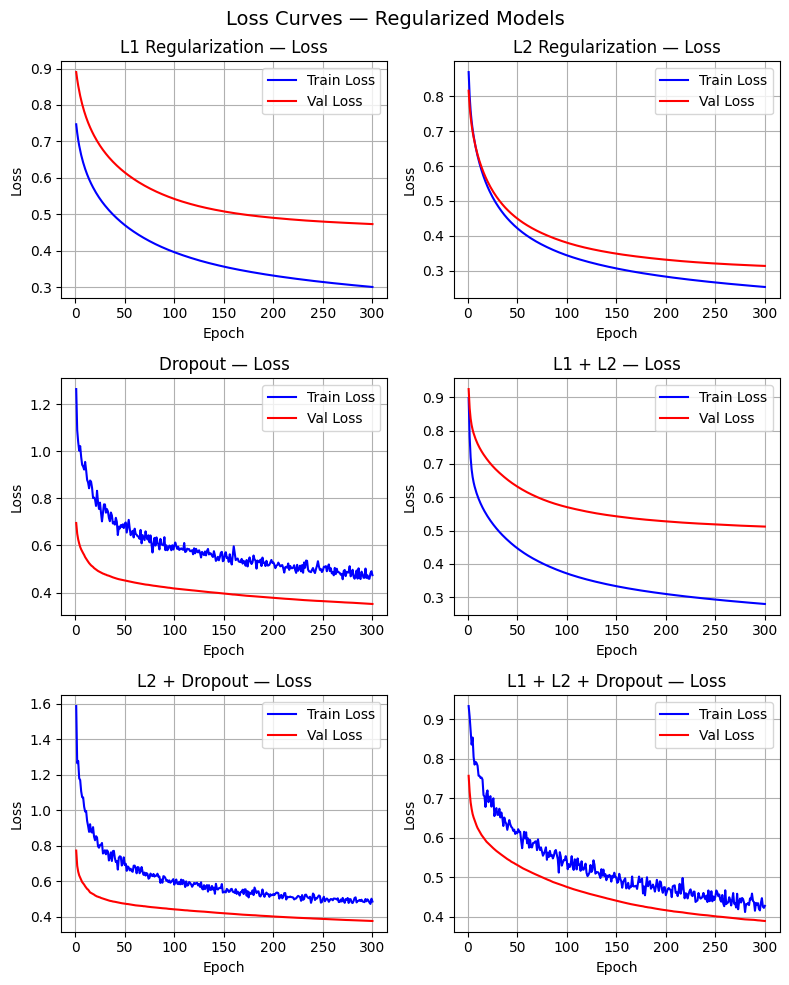

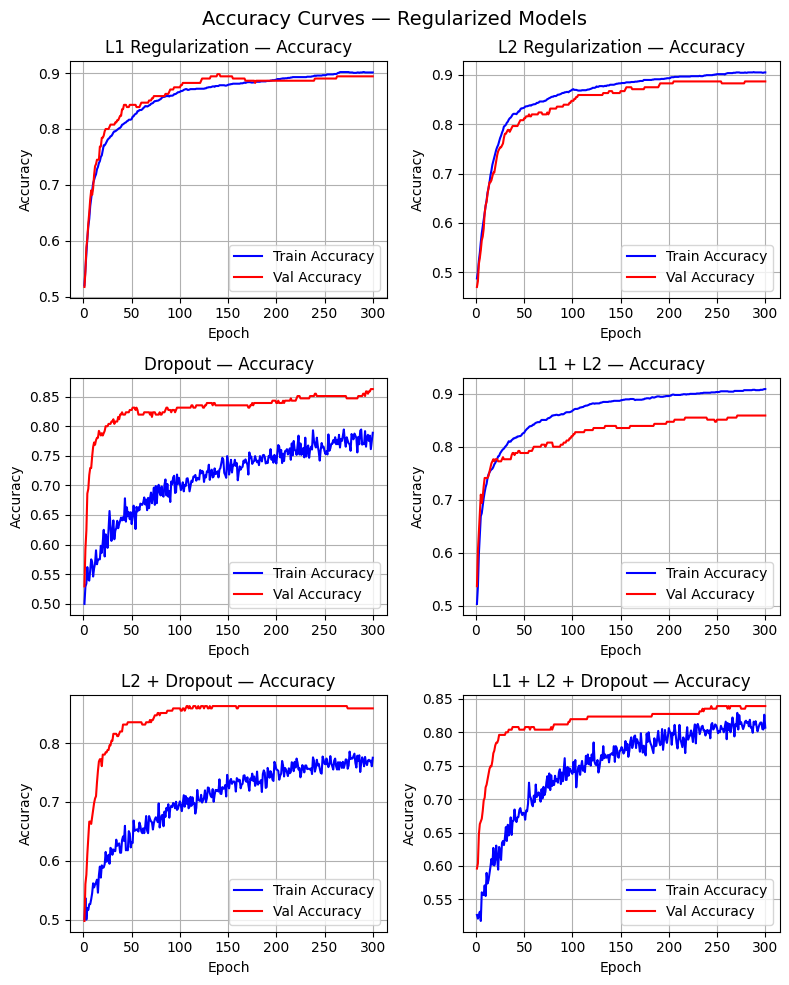

In [75]:
fig, axes = plt.subplots(3, 2, figsize=(8, 10))

models = [
    (train_losses_l1,   val_losses_l1,   train_acc_l1,   val_acc_l1,   'L1 Regularization'),
    (train_losses_l2,   val_losses_l2,   train_acc_l2,   val_acc_l2,   'L2 Regularization'),
    (train_losses_do,   val_losses_do,   train_acc_do,   val_acc_do,   'Dropout'),
    (train_losses_l1l2, val_losses_l1l2, train_acc_l1l2, val_acc_l1l2, 'L1 + L2'),
    (train_losses_l2do, val_losses_l2do, train_acc_l2do, val_acc_l2do, 'L2 + Dropout'),
    (train_losses_all,  val_losses_all,  train_acc_all,  val_acc_all,  'L1 + L2 + Dropout'),
]

epochs_range = range(1, 301)

for idx, (tl, vl, ta, va, title) in enumerate(models):
    row = idx // 2
    col = idx  % 2

    axes[row][col].plot(epochs_range, tl, label='Train Loss', color='blue')
    axes[row][col].plot(epochs_range, vl, label='Val Loss',   color='red')
    axes[row][col].set_title(f'{title} — Loss')
    axes[row][col].set_xlabel('Epoch')
    axes[row][col].set_ylabel('Loss')
    axes[row][col].legend()
    axes[row][col].grid(True)

plt.suptitle('Loss Curves — Regularized Models', fontsize=14)
plt.tight_layout()
plt.show()

# ── Accuracy curves ──
fig2, axes2 = plt.subplots(3, 2, figsize=(8, 10))

for idx, (tl, vl, ta, va, title) in enumerate(models):
    row = idx // 2
    col = idx  % 2

    axes2[row][col].plot(epochs_range, ta, label='Train Accuracy', color='blue')
    axes2[row][col].plot(epochs_range, va, label='Val Accuracy',   color='red')
    axes2[row][col].set_title(f'{title} — Accuracy')
    axes2[row][col].set_xlabel('Epoch')
    axes2[row][col].set_ylabel('Accuracy')
    axes2[row][col].legend()
    axes2[row][col].grid(True)

plt.suptitle('Accuracy Curves — Regularized Models', fontsize=14)
plt.tight_layout()
plt.show()

In [71]:
def predict(X, weights, biases):
    cache, _ = forward(X, weights, biases, dropout_rate=0.0, training=False)
    y_prob  = cache[-1].flatten()
    y_pred  = (y_prob >= 0.5).astype(int)
    return y_prob, y_pred

print("Prediction function defined")

Prediction function defined



  Overfit (No Regularization)
  Confusion Matrix:
    TN: 131  FP: 15
    FN: 20  TP: 134
  Precision : 0.8993
  Recall    : 0.8701
  F1 Score  : 0.8845
  ROC AUC   : 0.9380

  L1 Regularization
  Confusion Matrix:
    TN: 118  FP: 28
    FN: 12  TP: 142
  Precision : 0.8353
  Recall    : 0.9221
  F1 Score  : 0.8765
  ROC AUC   : 0.9234

  L2 Regularization
  Confusion Matrix:
    TN: 123  FP: 23
    FN: 15  TP: 139
  Precision : 0.8580
  Recall    : 0.9026
  F1 Score  : 0.8797
  ROC AUC   : 0.9290

  Dropout
  Confusion Matrix:
    TN: 118  FP: 28
    FN: 11  TP: 143
  Precision : 0.8363
  Recall    : 0.9286
  F1 Score  : 0.8800
  ROC AUC   : 0.9292

  L1 + L2
  Confusion Matrix:
    TN: 125  FP: 21
    FN: 19  TP: 135
  Precision : 0.8654
  Recall    : 0.8766
  F1 Score  : 0.8710
  ROC AUC   : 0.9227

  L2 + Dropout
  Confusion Matrix:
    TN: 121  FP: 25
    FN: 14  TP: 140
  Precision : 0.8485
  Recall    : 0.9091
  F1 Score  : 0.8777
  ROC AUC   : 0.9197

  L1 + L2 + Dropout
  Co

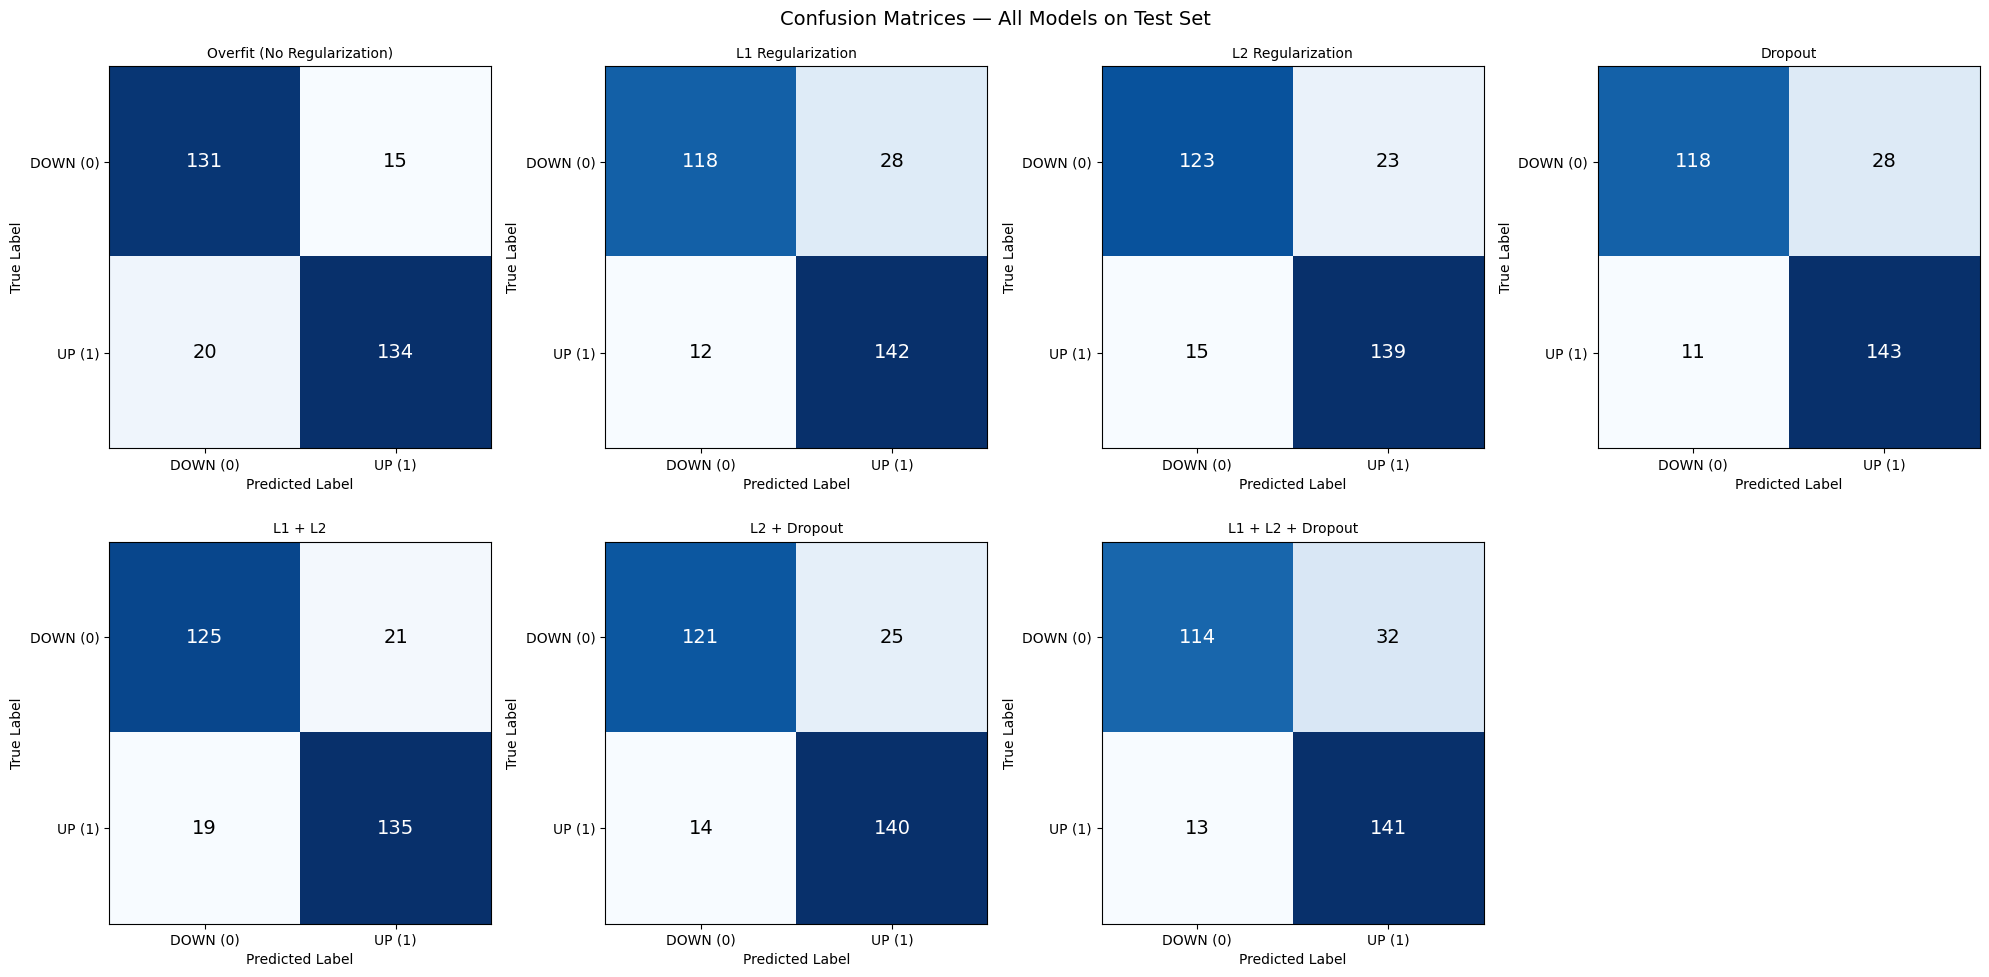

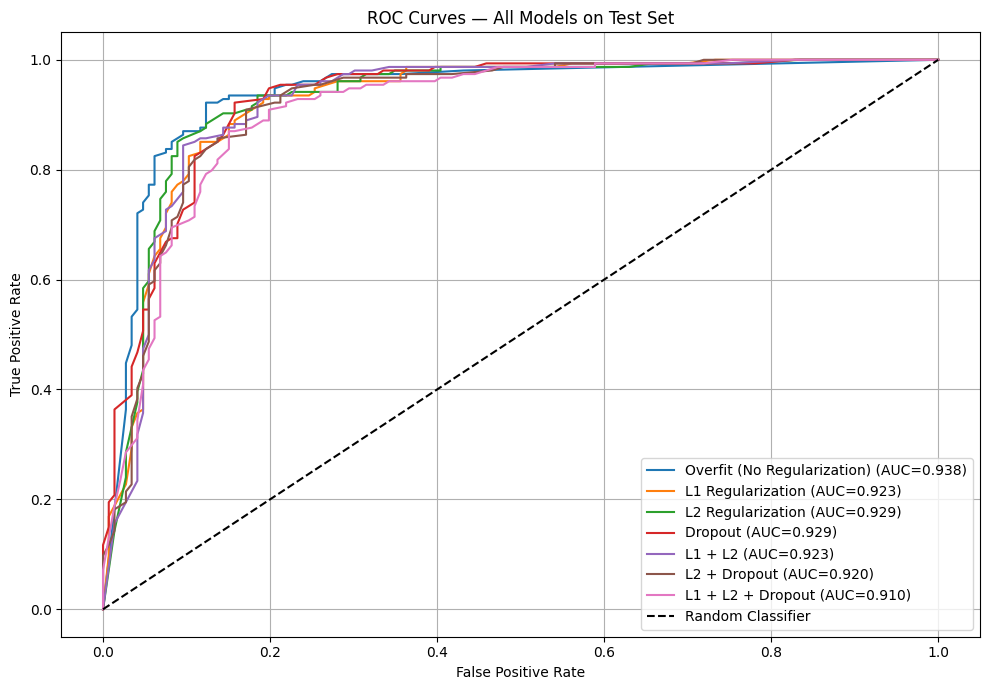



  Model                         F1   Prec    Rec    AUC
  Overfit (No Regularization)  0.884  0.899  0.870  0.938
  L1 Regularization          0.877  0.835  0.922  0.923
  L2 Regularization          0.880  0.858  0.903  0.929
  Dropout                    0.880  0.836  0.929  0.929
  L1 + L2                    0.871  0.865  0.877  0.923
  L2 + Dropout               0.878  0.848  0.909  0.920
  L1 + L2 + Dropout          0.862  0.815  0.916  0.910


In [ ]:
models_eval = [
    (weights_overfit, biases_overfit, 'Overfit (No Regularization)'),
    (weights_l1,      biases_l1,      'L1 Regularization'),
    (weights_l2,      biases_l2,      'L2 Regularization'),
    (weights_do,      biases_do,      'Dropout'),
    (weights_l1l2,    biases_l1l2,    'L1 + L2'),
    (weights_l2do,    biases_l2do,    'L2 + Dropout'),
    (weights_all,     biases_all,     'L1 + L2 + Dropout'),
]

for weights, biases, name in models_eval:
    y_prob, y_pred = predict(X_test, weights, biases)

    cm        = confusion_matrix(y_test, y_pred)
    f1        = f1_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall    = recall_score(y_test, y_pred)
    roc_auc   = roc_auc_score(y_test, y_prob)

    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(f"  Confusion Matrix:")
    print(f"    TN: {cm[0][0]}  FP: {cm[0][1]}")
    print(f"    FN: {cm[1][0]}  TP: {cm[1][1]}")
    print(f"  Precision : {precision:.4f}")
    print(f"  Recall    : {recall:.4f}")
    print(f"  F1 Score  : {f1:.4f}")
    print(f"  ROC AUC   : {roc_auc:.4f}")

# ── Confusion matrices plot ──
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, (weights, biases, name) in enumerate(models_eval):
    y_prob, y_pred = predict(X_test, weights, biases)
    cm = confusion_matrix(y_test, y_pred)

    im = axes[idx].imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    axes[idx].set_title(name, fontsize=10)
    axes[idx].set_xlabel('Predicted Label')
    axes[idx].set_ylabel('True Label')
    axes[idx].set_xticks([0, 1])
    axes[idx].set_yticks([0, 1])
    axes[idx].set_xticklabels(['DOWN (0)', 'UP (1)'])
    axes[idx].set_yticklabels(['DOWN (0)', 'UP (1)'])

    for i in range(2):
        for j in range(2):
            axes[idx].text(j, i, str(cm[i][j]),
                          ha='center', va='center',
                          color='white' if cm[i][j] > cm.max()/2 else 'black',
                          fontsize=14)

axes[-1].axis('off')
plt.suptitle('Confusion Matrices — All Models on Test Set', fontsize=14)
plt.tight_layout()
plt.show()

# ── ROC curves plot ──
fig, ax = plt.subplots(figsize=(7, 4))

for weights, biases, name in models_eval:
    y_prob, _ = predict(X_test, weights, biases)
    fpr, tpr  = [], []
    thresholds = np.linspace(0, 1, 100)

    for thresh in thresholds:
        y_pred_t = (y_prob >= thresh).astype(int)
        tp = np.sum((y_pred_t == 1) & (y_test == 1))
        fp = np.sum((y_pred_t == 1) & (y_test == 0))
        tn = np.sum((y_pred_t == 0) & (y_test == 0))
        fn = np.sum((y_pred_t == 0) & (y_test == 1))
        tpr.append(tp / (tp + fn + 1e-9))
        fpr.append(fp / (fp + tn + 1e-9))

    roc_auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, label=f'{name} (AUC={roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models on Test Set')
ax.legend(loc='lower right')
ax.grid(True)
plt.tight_layout()
plt.show()

# ── Final comparison table ──
print("\n")
print("="*65)
print(f"  {'Model':<25} {'F1':>6} {'Prec':>6} {'Rec':>6} {'AUC':>6}")
print("="*65)
for weights, biases, name in models_eval:
    y_prob, y_pred = predict(X_test, weights, biases)
    f1        = f1_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall    = recall_score(y_test, y_pred)
    roc_auc   = roc_auc_score(y_test, y_prob)
    print(f"  {name:<25} {f1:>6.3f} {precision:>6.3f} {recall:>6.3f} {roc_auc:>6.3f}")
print("="*65)